In [55]:
import os
import pandas as pd
import numpy as np
from rapidfuzz import process, fuzz
from nltk.tokenize import sent_tokenize
import nltk
nltk.download("punkt")
nltk.download("stopwords")
import re
from sklearn.impute import SimpleImputer
from sentence_transformers import SentenceTransformer
import os
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
import shap
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
import ast
import nltk
from xgboost import XGBClassifier
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import f1_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import itertools
from tqdm import tqdm
from sklearn.dummy import DummyClassifier
from collections import Counter
from scipy.stats import binom
import shap
from scipy.stats import spearmanr, mannwhitneyu
from scipy.spatial.distance import jensenshannon
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from copy import deepcopy
import warnings
warnings.filterwarnings("ignore")
from tqdm.notebook import tqdm
from tqdm import tqdm


[nltk_data] Downloading package punkt to /Users/bao/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/bao/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## PREPROCESSING

In [56]:
# Thư mục chứa scripts
folder_path = "./imsdbfilmscripts"

# Danh sách để lưu dữ liệu
data = []

# Duyệt tất cả file .txt trong folder
for filename in os.listdir(folder_path):
    if filename.endswith(".txt"):
        movie_name = os.path.splitext(filename)[0]  # tên file bỏ .txt
        file_path = os.path.join(folder_path, filename)
        with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
            movie_script = f.read().replace("\n", " ")  # chuyển xuống dòng thành space
        data.append([movie_name, movie_script])

# Tạo DataFrame
df = pd.DataFrame(data, columns=["movie_name", "movie_script"])

# Xuất ra CSV
#df.to_csv("movies_scripts.csv", index=False, encoding="utf-8")
print("Done! CSV saved as movies_scripts.csv")

Done! CSV saved as movies_scripts.csv


In [57]:
df["movie_name"] = df["movie_name"].str.replace("-", " ")

In [58]:
df

,movie_name,movie_script
0,Midnight Express,MIDNIG...
1,Speed,Speed Script at IMSDb. This script was...
2,Big Eyes,...
3,Warrior,WARRIOR ...
4,Hellraiser Hellseeker,HELLRAISER: HELLSEEKER ...
...,...,...
1160,Silver Linings Playbook,SILVER LININGS...
1161,"Prestige, The",THE P...
1162,Four Rooms,"""FOUR R..."
1163,"Theory of Everything, The",THE THEORY...


In [59]:
ratings = pd.read_csv("data/title.ratings.tsv", sep="\t")
basics = pd.read_csv("data/title.basics.tsv", sep="\t", low_memory=False)

# Keep only movies
basics = basics[basics["titleType"] == "movie"]

# Merge ratings with titles
imdb = basics.merge(ratings, on="tconst")

def normalize_title(title):
    if pd.isna(title):
        return ""
    title = title.lower().strip()
    title = re.sub(r"[^\w\s]", "", title)  # remove punctuation
    title = re.sub(r"\s+", " ", title)     # normalize spaces
    return title

imdb["title_norm"] = imdb["primaryTitle"].apply(normalize_title)

# Deduplicate (keep highest votes per title)
imdb_unique = (
    imdb.sort_values("numVotes", ascending=False)
        .drop_duplicates(subset=["title_norm"])
)

In [60]:
# 3. Prepare fuzzy matching
# =========================
title_choices = imdb_unique["title_norm"].tolist()

# Map normalized title -> rating
title_to_rating = dict(zip(
    imdb_unique["title_norm"],
    imdb_unique["averageRating"]
))

# Normalize your dataset
df["movie_name_norm"] = df["movie_name"].apply(normalize_title)


In [61]:
# 4. Fuzzy matching function
# =========================
def get_best_match(title, threshold=85):
    match, score, _ = process.extractOne(
        title,
        title_choices,
        scorer=fuzz.WRatio
    )
    if score >= threshold:
        return match
    return None

# Apply fuzzy matching
df["matched_title"] = df["movie_name_norm"].apply(get_best_match)

# Map rating
df["averageRating"] = df["matched_title"].map(title_to_rating)

# =========================
# 5. Cleanup
# =========================
df = df.drop(columns=["movie_name_norm", "matched_title"])

In [62]:
df.shape

(1165, 3)

In [63]:
def preprocess_sentence(sent: str) -> str:
    sent = re.sub(r'</?b>', '', sent)
    sent = re.sub(r'<!--.*?-->', '', sent, flags=re.DOTALL)
    sent = re.sub(r'/\*.*?\*/', '', sent, flags=re.DOTALL)
    sent = re.sub(r'//.*', '', sent)
    sent = re.sub(r"\(.*?\)", "", sent)
    #sent = re.sub(r"^\s*[A-Z][A-Z\s\.\(\)\']{2,}\s*$", "", sent, flags=re.MULTILINE)
    sent = re.sub(r"^\s*(FADE IN|FADE OUT|CUT TO|DISSOLVE TO|SMASH CUT).*$",
                  "", sent, flags=re.MULTILINE | re.IGNORECASE)
    sent = re.sub(r"\s+", " ", sent).strip()
    return sent.lower()

In [64]:
def extract_sentences(text: str) -> list[str]:
    sentences = nltk.sent_tokenize(text)
    # Filter out very short fragments (< 10 characters) that add no signal
    sentences = [s.strip() for s in sentences if len(s.strip()) >= 10]
    return sentences

In [65]:
def build_embeddings(df, model, window=2):
    all_embeddings = []
    all_raw_kept   = []   # ← thêm dòng này

    for raw_script in tqdm(df["movie_script"], desc="Embedding"):
        sents = extract_sentences(raw_script)
        pairs = [(raw, preprocess_sentence(raw)) for raw in sents]
        pairs = [(raw, clean) for raw, clean in pairs if clean]

        if not pairs:
            all_embeddings.append(np.zeros((1, 384), dtype=np.float32))
            all_raw_kept.append([""])
            continue

        raw_kept   = [p[0] for p in pairs]
        clean_kept = [p[1] for p in pairs]

        contexted = []
        for i in range(len(clean_kept)):
            start = max(0, i - window)
            end   = min(len(clean_kept), i + window + 1)
            contexted.append(" ".join(clean_kept[start:end]))

        embeddings = model.encode(
            contexted, batch_size=64,
            show_progress_bar=False,
            convert_to_numpy=True
        )
        all_embeddings.append(embeddings.astype(np.float32))
        all_raw_kept.append(raw_kept)   # ← lưu raw đã filter, không phải raw gốc

    df = df.copy()
    df["sent_emb"]  = all_embeddings
    df["sentences"] = all_raw_kept    # ← aligned với sent_emb
    return df

In [66]:
sbert_model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7428.78it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [67]:
df = build_embeddings(df, sbert_model, window=2)

Embedding: 100%|██████████| 1165/1165 [2:32:01<00:00,  7.83s/it]   


In [68]:
shapes = df["sent_emb"].apply(lambda e: e.shape[0])
print(shapes.describe())
print(f"\nPhim có shape (1,384) — script rỗng sau clean: {(shapes == 1).sum()}")
print(df[shapes == 1][["movie_name", "averageRating"]])

count    1165.000000
mean     2525.014592
std       716.328273
min         1.000000
25%      2208.000000
50%      2555.000000
75%      2907.000000
max      6018.000000
Name: sent_emb, dtype: float64

Phim có shape (1,384) — script rỗng sau clean: 6
                  movie_name  averageRating
94     Shadow of the Vampire            6.9
267                Apollo 13            7.7
319            Scary Movie 2            5.4
881   Neverending Story, The            7.3
910                   8 Mile            7.2
1019                 Robocop            7.6


In [69]:
df2 = df[shapes >= 10].copy().reset_index(drop=True)
print(f"Còn lại: {len(df2)} phim")

Còn lại: 1140 phim


In [70]:
df2

,movie_name,movie_script,averageRating,sent_emb,sentences
0,Midnight Express,MIDNIG...,7.5,"[[-0.021538744, -0.023990724, 0.005766647, 0.0...",[MIDNIGHT EXPRESS ...
1,Big Eyes,...,6.9,"[[0.0006504674, 0.033903405, 0.02118536, 0.027...",[BIG EYES ...
2,Warrior,WARRIOR ...,8.1,"[[-0.03370627, 0.06670329, 0.0409536, -0.00289...",[WARRIOR ...
3,Hellraiser Hellseeker,HELLRAISER: HELLSEEKER ...,6.9,"[[0.021127773, 0.09984054, -0.018924795, 0.029...",[HELLRAISER: HELLSEEKER ...
4,Hannah and Her Sisters,<b><!-- </b> <b>/* </b>Break-out-of-frames ...,7.8,"[[-0.018686373, -0.0055099637, -0.00020438943,...",[<b><!-- </b> <b>/* </b>Break-out-of-frames sc...
...,...,...,...,...,...
1135,Silver Linings Playbook,SILVER LININGS...,7.7,"[[-0.04288741, 0.035266433, 0.0010719461, 0.02...",[SILVER LININGS PLAYBOOK ...
1136,"Prestige, The",THE P...,8.5,"[[0.0018083804, 0.026148373, 0.0030122846, 0.0...",[THE PRESTIGE ...
1137,Four Rooms,"""FOUR R...",6.7,"[[0.059544943, -0.071963124, -0.011419173, 0.0...","[""FOUR ROOMS"" ..."
1138,"Theory of Everything, The",THE THEORY...,7.7,"[[-0.0011777821, -0.09174389, 0.019669631, 0.0...",[THE THEORY OF EVERYTHING ...


In [71]:
df2["sent_emb"][0]

array([[-0.02153874, -0.02399072,  0.00576665, ...,  0.09238402,
         0.01766618, -0.02752273],
       [-0.00502766, -0.02026292,  0.00687942, ...,  0.0775222 ,
         0.01072645, -0.03501723],
       [-0.00931381, -0.02135008,  0.01329667, ...,  0.07447056,
         0.00309085, -0.03465235],
       ...,
       [-0.03742879, -0.02537896, -0.03647301, ...,  0.06388173,
        -0.04576573,  0.01761298],
       [-0.05417375, -0.05405987, -0.04661817, ...,  0.06150055,
        -0.03124914,  0.02195732],
       [-0.05824892, -0.03842977, -0.0509924 , ...,  0.05632223,
        -0.04540097,  0.02463016]], shape=(2571, 384), dtype=float32)

In [72]:
#remove 
mask = (df2["averageRating"] <= 6.5) | (df2["averageRating"] >= 7.5)
df_clean = df2[mask].copy()
df_clean
df_clean["rating_label"] = (df_clean["averageRating"] >= 7.5).astype(int)

print(f"Remaining: {len(df_clean)} movies")
print(df_clean["rating_label"].value_counts(normalize=True))

Remaining: 698 movies
rating_label
0    0.505731
1    0.494269
Name: proportion, dtype: float64


In [73]:
df_clean

,movie_name,movie_script,averageRating,sent_emb,sentences,rating_label
0,Midnight Express,MIDNIG...,7.5,"[[-0.021538744, -0.023990724, 0.005766647, 0.0...",[MIDNIGHT EXPRESS ...,1
2,Warrior,WARRIOR ...,8.1,"[[-0.03370627, 0.06670329, 0.0409536, -0.00289...",[WARRIOR ...,1
4,Hannah and Her Sisters,<b><!-- </b> <b>/* </b>Break-out-of-frames ...,7.8,"[[-0.018686373, -0.0055099637, -0.00020438943,...",[<b><!-- </b> <b>/* </b>Break-out-of-frames sc...,1
5,"Graduate, The",<b><!-- </b>if (window!= top) top.location....,8.0,"[[-0.029912792, 0.02471665, -0.00079140003, 0....",[<b><!-- </b>if (window!= top) top.location.hr...,1
6,Cinema Paradiso,CINEMA PARADISO by Giuseppe Tornatore \t\t...,8.5,"[[-0.0060971486, 0.033444464, -0.003336626, 0....",[CINEMA PARADISO by Giuseppe Tornatore \t\...,1
...,...,...,...,...,...,...
1133,"Surfer King, The",THE ...,3.9,"[[-0.0069497256, -0.013766917, -0.026492234, 0...",[THE SURFER KING ...,0
1134,Misery,Misery - by William Goldman <b><!-- </b>if (...,7.8,"[[-0.045991223, 0.08743706, -0.032433532, 0.13...",[Misery - by William Goldman <b><!-- </b>if ...,1
1135,Silver Linings Playbook,SILVER LININGS...,7.7,"[[-0.04288741, 0.035266433, 0.0010719461, 0.02...",[SILVER LININGS PLAYBOOK ...,1
1136,"Prestige, The",THE P...,8.5,"[[0.0018083804, 0.026148373, 0.0030122846, 0.0...",[THE PRESTIGE ...,1


In [74]:
# df_clean = df_clean[df_clean["sentences"].apply(len) > 2].reset_index(drop=True)
# print(f"Remaining movies: {len(df_clean)}")

## PREPARE

In [75]:
import re
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight

In [76]:
def detect_scene_boundaries(sentences):
    pattern = re.compile(r'^(INT\.|EXT\.|INT/EXT\.|I/E\.)\s+.+', re.IGNORECASE)
    boundaries = [i for i, s in enumerate(sentences) if pattern.match(s.strip())]
    if len(boundaries) < 5:
        n = len(sentences)
        boundaries = list(range(0, n, max(1, n // 20)))
    return boundaries

In [77]:
def split_into_scenes(emb, sentences, n_scenes=20):
    """Chia script thành n_scenes, mỗi scene mean-pooled thành 1 vector (384,)"""
    emb = np.array(emb, dtype=np.float32)
    boundaries = detect_scene_boundaries(sentences)

    if len(boundaries) >= 5:
        scenes = []
        for i, start in enumerate(boundaries):
            end = boundaries[i+1] if i+1 < len(boundaries) else len(emb)
            chunk = emb[start:end]
            if len(chunk) > 0:
                scenes.append(chunk.mean(axis=0))
    else:
        chunks = np.array_split(emb, n_scenes, axis=0)
        scenes = [c.mean(axis=0) for c in chunks if len(c) > 0]

    scenes = np.stack(scenes)   # (raw_n_scenes, 384)

    # Pad hoặc truncate về đúng n_scenes
    if len(scenes) >= n_scenes:
        return scenes[:n_scenes]
    pad = np.zeros((n_scenes - len(scenes), 384), dtype=np.float32)
    return np.vstack([scenes, pad])

In [78]:
def prepare_scene_tensors(idx_list, embeddings_list, labels, df, n_scenes=20):
    scene_list = []
    for i in idx_list:
        emb   = embeddings_list[i]
        sents = df["sentences"].iloc[i] if "sentences" in df.columns else []
        scene_list.append(split_into_scenes(emb, sents, n_scenes))
    X = torch.tensor(np.stack(scene_list), dtype=torch.float32)  # (N, n_scenes, 384)
    y = torch.tensor([labels[i] for i in idx_list], dtype=torch.long)
    return X, y

In [79]:
df_clean.head()

,movie_name,movie_script,averageRating,sent_emb,sentences,rating_label
0,Midnight Express,MIDNIG...,7.5,"[[-0.021538744, -0.023990724, 0.005766647, 0.0...",[MIDNIGHT EXPRESS ...,1
2,Warrior,WARRIOR ...,8.1,"[[-0.03370627, 0.06670329, 0.0409536, -0.00289...",[WARRIOR ...,1
4,Hannah and Her Sisters,<b><!-- </b> <b>/* </b>Break-out-of-frames ...,7.8,"[[-0.018686373, -0.0055099637, -0.00020438943,...",[<b><!-- </b> <b>/* </b>Break-out-of-frames sc...,1
5,"Graduate, The",<b><!-- </b>if (window!= top) top.location....,8.0,"[[-0.029912792, 0.02471665, -0.00079140003, 0....",[<b><!-- </b>if (window!= top) top.location.hr...,1
6,Cinema Paradiso,CINEMA PARADISO by Giuseppe Tornatore \t\t...,8.5,"[[-0.0060971486, 0.033444464, -0.003336626, 0....",[CINEMA PARADISO by Giuseppe Tornatore \t\...,1


In [80]:
def make_splits(df_clean):
    embeddings_list = [np.array(e, dtype=np.float32) for e in df_clean["sent_emb"]]
    labels          = df_clean["rating_label"].tolist()
    idx             = list(range(len(labels)))

    train_idx, temp_idx = train_test_split(
        idx, test_size=0.3, random_state=42, stratify=labels)
    val_idx, test_idx   = train_test_split(
        temp_idx, test_size=0.5, random_state=42,
        stratify=[labels[i] for i in temp_idx])

    print(f"Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}")
    print(f"Train labels: {Counter([labels[i] for i in train_idx])}")
    return embeddings_list, labels, train_idx, val_idx, test_idx

In [81]:
embeddings_list, labels, train_idx, val_idx, test_idx = make_splits(df_clean)

Train: 488, Val: 105, Test: 105
Train labels: Counter({0: 247, 1: 241})


## CONVOLUTIONAL BACKBONE

In [82]:
import itertools
from copy import deepcopy

def build_and_train(cfg, X_tr, y_tr, X_v, y_v, max_epochs=80, patience=10):
    hidden  = cfg["hidden"]
    dropout = cfg["dropout"]

    s_proj  = nn.Sequential(
        nn.Linear(384, hidden), nn.ReLU(), nn.Dropout(dropout))
    a_conv  = nn.Sequential(
        nn.Conv1d(hidden, hidden, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Conv1d(hidden, hidden, kernel_size=3, padding=2, dilation=2),
        nn.ReLU(),
    )
    clf_head = nn.Linear(hidden, 2)

    params    = (list(s_proj.parameters()) +
                 list(a_conv.parameters()) +
                 list(clf_head.parameters()))
    optimizer = torch.optim.AdamW(params,
                                   lr=cfg["lr"],
                                   weight_decay=cfg["weight_decay"])

    weights   = compute_class_weight("balanced",
                                      classes=np.array([0, 1]),
                                      y=y_tr.numpy())
    loss_fn   = nn.CrossEntropyLoss(
        weight=torch.tensor(weights, dtype=torch.float32))
    loader    = DataLoader(TensorDataset(X_tr, y_tr),
                           batch_size=16, shuffle=True)

    def fwd(x):
        sv       = s_proj(x)
        af       = a_conv(sv.transpose(1, 2))
        return clf_head(af.mean(dim=2)), af

    best_f1, best_state, pat = 0.0, None, 0

    for epoch in range(max_epochs):
        s_proj.train(); a_conv.train(); clf_head.train()
        for xb, yb in loader:
            optimizer.zero_grad()
            logits, _ = fwd(xb)
            loss_fn(logits, yb).backward()
            torch.nn.utils.clip_grad_norm_(params, 1.0)
            optimizer.step()

        s_proj.eval(); a_conv.eval(); clf_head.eval()
        with torch.no_grad():
            preds = fwd(X_v)[0].argmax(1).numpy()
        f1 = f1_score(y_v.numpy(), preds, average="macro")

        if f1 > best_f1:
            best_f1 = f1
            best_state = {
                "s_proj":   deepcopy(s_proj.state_dict()),
                "a_conv":   deepcopy(a_conv.state_dict()),
                "clf_head": deepcopy(clf_head.state_dict()),
            }
            pat = 0
        else:
            pat += 1
            if pat >= patience:
                break

    return best_f1, best_state, cfg

In [83]:
def run_grid_search(embeddings_list, labels, train_idx, val_idx, df_clean):
    GRID = {
        "n_scenes":     [10, 20, 30],
        "hidden":       [16, 32, 64],
        "dropout":      [0.3, 0.4, 0.5],
        "lr":           [1e-3, 3e-4],
        "weight_decay": [1e-3, 1e-4],
    }
    all_configs = [dict(zip(GRID.keys(), v))
                   for v in itertools.product(*GRID.values())]
    print(f"Tổng configs: {len(all_configs)}")

    results = []
    for i, cfg in enumerate(all_configs):
        n = cfg["n_scenes"]
        X_tr, y_tr = prepare_scene_tensors(train_idx, embeddings_list, labels, df_clean, n)
        X_v,  y_v = prepare_scene_tensors(val_idx,   embeddings_list, labels, df_clean, n)
        f1, state, _ = build_and_train(cfg, X_tr, y_tr, X_v, y_v)
        results.append({"config": cfg, "val_f1": f1, "state": state})
        print(f"[{i+1:3d}/{len(all_configs)}] n={n} h={cfg['hidden']} "
              f"do={cfg['dropout']} lr={cfg['lr']:.0e} → f1={f1:.3f}")

    results.sort(key=lambda r: r["val_f1"], reverse=True)
    best = results[0]
    print(f"\nBest val_f1 = {best['val_f1']:.3f}")
    print(f"Config      = {best['config']}")
    return best, all_configs

In [84]:
best, all_configs = run_grid_search(embeddings_list, labels, train_idx, val_idx, df_clean)

Tổng configs: 108
[  1/108] n=10 h=16 do=0.3 lr=1e-03 → f1=0.714
[  2/108] n=10 h=16 do=0.3 lr=1e-03 → f1=0.704
[  3/108] n=10 h=16 do=0.3 lr=3e-04 → f1=0.695
[  4/108] n=10 h=16 do=0.3 lr=3e-04 → f1=0.724
[  5/108] n=10 h=16 do=0.4 lr=1e-03 → f1=0.711
[  6/108] n=10 h=16 do=0.4 lr=1e-03 → f1=0.743
[  7/108] n=10 h=16 do=0.4 lr=3e-04 → f1=0.714
[  8/108] n=10 h=16 do=0.4 lr=3e-04 → f1=0.695
[  9/108] n=10 h=16 do=0.5 lr=1e-03 → f1=0.705
[ 10/108] n=10 h=16 do=0.5 lr=1e-03 → f1=0.695
[ 11/108] n=10 h=16 do=0.5 lr=3e-04 → f1=0.694
[ 12/108] n=10 h=16 do=0.5 lr=3e-04 → f1=0.685
[ 13/108] n=10 h=32 do=0.3 lr=1e-03 → f1=0.714
[ 14/108] n=10 h=32 do=0.3 lr=1e-03 → f1=0.713
[ 15/108] n=10 h=32 do=0.3 lr=3e-04 → f1=0.721
[ 16/108] n=10 h=32 do=0.3 lr=3e-04 → f1=0.714
[ 17/108] n=10 h=32 do=0.4 lr=1e-03 → f1=0.704
[ 18/108] n=10 h=32 do=0.4 lr=1e-03 → f1=0.704
[ 19/108] n=10 h=32 do=0.4 lr=3e-04 → f1=0.733
[ 20/108] n=10 h=32 do=0.4 lr=3e-04 → f1=0.720
[ 21/108] n=10 h=32 do=0.5 lr=1e-03 → f1=0

In [85]:
def load_best_model(best):
    cfg   = best["config"]
    state = best["state"]
    s_proj = nn.Sequential(
        nn.Linear(384, cfg["hidden"]), nn.ReLU(), nn.Dropout(cfg["dropout"]))
    a_conv = nn.Sequential(
        nn.Conv1d(cfg["hidden"], cfg["hidden"], kernel_size=3, padding=1),
        nn.ReLU(), nn.Dropout(cfg["dropout"]),
        nn.Conv1d(cfg["hidden"], cfg["hidden"], kernel_size=3, padding=2, dilation=2),
        nn.ReLU())
    clf_head = nn.Linear(cfg["hidden"], 2)
    s_proj.load_state_dict(state["s_proj"])
    a_conv.load_state_dict(state["a_conv"])
    clf_head.load_state_dict(state["clf_head"])
    return s_proj, a_conv, clf_head

In [86]:
scene_proj, arc_conv, classifier_head = load_best_model(best)
best_cfg   = best["config"]
best_state = best["state"]
N_SCENES   = best_cfg["n_scenes"]

In [87]:
#val set
n = best_cfg["n_scenes"]
X_val, y_val = prepare_scene_tensors(
    val_idx, embeddings_list, labels, df_clean, n)

scene_proj.eval(); arc_conv.eval(); classifier_head.eval()

with torch.no_grad():
    sv       = scene_proj(X_val)
    af       = arc_conv(sv.transpose(1, 2))
    logits   = classifier_head(af.mean(dim=2))
    preds    = logits.argmax(1).numpy()
    probs    = torch.softmax(logits, dim=1).numpy()  # xác suất mỗi class

from sklearn.metrics import classification_report
print(classification_report(y_val.numpy(), preds,
                              target_names=["bad", "good"]))

              precision    recall  f1-score   support

         bad       0.75      0.74      0.74        53
        good       0.74      0.75      0.74        52

    accuracy                           0.74       105
   macro avg       0.74      0.74      0.74       105
weighted avg       0.74      0.74      0.74       105



In [88]:
#test set (final report)
n = best_cfg["n_scenes"]
X_test_best, y_test_best = prepare_scene_tensors(
    test_idx, embeddings_list, labels, df_clean, n)

scene_proj.eval(); arc_conv.eval(); classifier_head.eval()

with torch.no_grad():
    sv       = scene_proj(X_test_best)
    af       = arc_conv(sv.transpose(1, 2))
    logits   = classifier_head(af.mean(dim=2))
    preds    = logits.argmax(1).numpy()
    probs    = torch.softmax(logits, dim=1).numpy() 

from sklearn.metrics import classification_report
print(classification_report(y_test_best.numpy(), preds,
                              target_names=["bad", "good"]))

              precision    recall  f1-score   support

         bad       0.67      0.60      0.63        53
        good       0.63      0.69      0.66        52

    accuracy                           0.65       105
   macro avg       0.65      0.65      0.65       105
weighted avg       0.65      0.65      0.65       105



In [89]:
# X_train_s, y_train_s = prepare_scene_tensors(train_idx, embeddings_list, labels, df_clean, N_SCENES)
# X_val_s,   y_val_s   = prepare_scene_tensors(val_idx,   embeddings_list, labels, df_clean, N_SCENES)
# X_test_s,  y_test_s  = prepare_scene_tensors(test_idx,  embeddings_list, labels, df_clean, N_SCENES)

## Compare baseline LR/XGB and Convo LR/XGB

In [90]:
def compare_baselines(embeddings_list, labels, train_idx, val_idx, test_idx,
                      scene_proj, arc_conv, classifier_head, best_cfg, df_clean):

    # 1. Train again Conv on train + val
    n = best_cfg["n_scenes"]

    X_tv_t, y_tv_t = prepare_scene_tensors(
        train_idx + val_idx, embeddings_list, labels, df_clean, n)
    X_te_t, y_te_t = prepare_scene_tensors(
        test_idx, embeddings_list, labels, df_clean, n)

    _, state_final, _ = build_and_train(
        best_cfg, X_tv_t, y_tv_t, X_te_t, y_te_t)

    scene_proj.load_state_dict(state_final["s_proj"])
    arc_conv.load_state_dict(state_final["a_conv"])
    classifier_head.load_state_dict(state_final["clf_head"])
    scene_proj.eval(); arc_conv.eval(); classifier_head.eval()
    print("Conv retrained on train+val.")


    # 2. prepare features
    def mean_pool(emb_list):
        return np.stack([np.array(e, dtype=np.float32).mean(axis=0)
                         for e in emb_list])

    def extract_conv_features(idx_list):
        X, _ = prepare_scene_tensors(
            idx_list, embeddings_list, labels, df_clean, n)
        scene_proj.eval(); arc_conv.eval()
        with torch.no_grad():
            af = arc_conv(scene_proj(X).transpose(1, 2))
        return af.mean(dim=2).numpy()

    X_tv_raw = mean_pool([embeddings_list[i] for i in train_idx + val_idx])
    X_te_raw = mean_pool([embeddings_list[i] for i in test_idx])
    F_tv     = extract_conv_features(train_idx + val_idx)
    F_te     = extract_conv_features(test_idx)
    y_tv     = np.array([labels[i] for i in train_idx + val_idx])
    y_te     = np.array([labels[i] for i in test_idx])
    sw       = (y_tv == 0).sum() / (y_tv == 1).sum()


    # 3. Fit baselines
    baselines = {
        "Majority class":  (DummyClassifier(strategy="most_frequent"),
                            X_tv_raw, X_te_raw),
        "LR  — raw SBERT": (LogisticRegression(max_iter=1000,
                                                class_weight="balanced",
                                                C=0.1),
                            X_tv_raw, X_te_raw),
        "XGB — raw SBERT": (XGBClassifier(n_estimators=200,
                                           eval_metric="logloss",
                                           scale_pos_weight=sw,
                                           random_state=42,
                                           verbosity=0),
                            X_tv_raw, X_te_raw),
        "LR  — Conv feat": (LogisticRegression(max_iter=1000,
                                                class_weight="balanced",
                                                C=0.1),
                            F_tv, F_te),
        "XGB — Conv feat": (XGBClassifier(n_estimators=200,
                                           eval_metric="logloss",
                                           scale_pos_weight=sw,
                                           random_state=42,
                                           verbosity=0),
                            F_tv, F_te),
    }

    for name, (clf, X_train, _) in baselines.items():
        clf.fit(X_train, y_tv)

    # 4. Predict Conv end-to-end

    with torch.no_grad():
        preds_conv = classifier_head(
            arc_conv(scene_proj(X_te_t).transpose(1, 2)).mean(dim=2)
        ).argmax(1).numpy()


    # 5. Report F1
    print(f"\n{'Model':<25} {'Test F1':>8}  {'Train data'}")
    print("-" * 55)

    preds_all = {}
    for name, (clf, _, X_test) in baselines.items():
        preds = clf.predict(X_test)
        preds_all[name] = preds
        f1 = f1_score(y_te, preds, average="macro")
        print(f"{name:<25} {f1:>8.3f}  train+val")

    f1_conv = f1_score(y_te, preds_conv, average="macro")
    preds_all["Conv end-to-end"] = preds_conv
    print(f"{'Conv end-to-end':<25} {f1_conv:>8.3f}  train+val")


    # 6. McNemar test vs Conv

    print(f"\n{'McNemar test vs Conv end-to-end'}")
    print("-" * 55)

    for name, preds in preds_all.items():
        if name == "Conv end-to-end":
            continue
        n10 = ((preds_conv == y_te) & (preds != y_te)).sum()
        n01 = ((preds_conv != y_te) & (preds == y_te)).sum()
        if n10 + n01 == 0:
            print(f"  vs {name:<22} identical predictions")
            continue
        p   = 2 * binom.cdf(min(n10, n01), n10 + n01, 0.5)
        sig = "✓ significant" if p < 0.05 else "✗ not significant"
        print(f"  vs {name:<22} n10={n10:3d} n01={n01:3d}"
              f"  p={p:.4f}  {sig}")

    # 7. Classification report Conv
    print("\n Classification report — Conv end-to-end")
    print(classification_report(y_te, preds_conv,
                                 target_names=["bad", "good"]))

    return {
        "baselines":   baselines,
        "preds_all":   preds_all,
        "preds_conv":  preds_conv,
        "y_te":        y_te,
        "f1_conv":     f1_conv,
    }

In [91]:
results = compare_baselines(
    embeddings_list, labels,
    train_idx, val_idx, test_idx,
    scene_proj, arc_conv, classifier_head,
    best_cfg, df_clean
)

Conv retrained on train+val.

Model                      Test F1  Train data
-------------------------------------------------------
Majority class               0.335  train+val
LR  — raw SBERT              0.579  train+val
XGB — raw SBERT              0.647  train+val
LR  — Conv feat              0.686  train+val
XGB — Conv feat              0.581  train+val
Conv end-to-end              0.676  train+val

McNemar test vs Conv end-to-end
-------------------------------------------------------
  vs Majority class         n10= 36 n01= 18  p=0.0198  ✓ significant
  vs LR  — raw SBERT        n10= 14 n01=  4  p=0.0309  ✓ significant
  vs XGB — raw SBERT        n10= 12 n01=  9  p=0.6636  ✗ not significant
  vs LR  — Conv feat        n10=  0 n01=  1  p=1.0000  ✗ not significant
  vs XGB — Conv feat        n10= 14 n01=  4  p=0.0309  ✓ significant

 Classification report — Conv end-to-end
              precision    recall  f1-score   support

         bad       0.69      0.66      0.67        5

## CAM

In [92]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def compute_cam(movie_idx, X_scene_tensor, scene_proj, arc_conv, classifier_head):
    x = X_scene_tensor[movie_idx].unsqueeze(0)
    scene_proj.eval(); arc_conv.eval(); classifier_head.eval()
    with torch.no_grad():
        sv       = scene_proj(x)
        af       = arc_conv(sv.transpose(1, 2))   # (1, hidden, N_SCENES)
        logits   = classifier_head(af.mean(dim=2))
        pred_class = logits.argmax(1).item()
        prob     = torch.softmax(logits, dim=1)[0][pred_class].item()

    feat = af.squeeze(0).numpy()                  # (hidden, N_SCENES)
    w    = classifier_head.weight[pred_class].detach().numpy()
    cam  = (w[:, None] * feat).sum(axis=0)        # (N_SCENES,)
    cam  = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam, pred_class, prob


def explain_movie(movie_idx, df_clean, X_scene_tensor, y_tensor,
                  scene_proj, arc_conv, classifier_head, N_SCENES):

    cam, pred_class, prob = compute_cam(
        movie_idx, X_scene_tensor, scene_proj, arc_conv, classifier_head)

    title      = df_clean["movie_name"].iloc[movie_idx]
    rating     = df_clean["averageRating"].iloc[movie_idx]
    true_label = "GOOD" if y_tensor[movie_idx].item() == 1 else "BAD"
    pred_label = "GOOD" if pred_class == 1 else "BAD"
    correct    = "✓" if true_label == pred_label else "✗"

    fig, ax = plt.subplots(figsize=(13, 4))
    colors = plt.cm.RdYlGn(cam)
    ax.bar(range(N_SCENES), cam, color=colors, width=0.85)

    # Act boundaries
    for b in [N_SCENES//3, 2*N_SCENES//3]:
        ax.axvline(b - 0.5, color="gray", linestyle="--",
                   linewidth=1.2, alpha=0.6)
    for pos, label in [(N_SCENES//6, "Act 1"),
                       (N_SCENES//2, "Act 2"),
                       (5*N_SCENES//6, "Act 3")]:
        ax.text(pos, 1.02, label, ha="center",
                transform=ax.get_xaxis_transform(),
                fontsize=9, color="gray")

    ax.set_xticks(range(N_SCENES))
    ax.set_xticklabels([f"S{i+1}" for i in range(N_SCENES)], fontsize=8)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("CAM score")
    ax.set_title(
        f"{title}  |  Rating {rating:.1f}  |  "
        f"True: {true_label}  Pred: {pred_label} ({prob:.0%})  {correct}"
    )

    red_p   = mpatches.Patch(color="#d73027", label="less important")
    green_p = mpatches.Patch(color="#1a9850", label="important for prediction")
    ax.legend(handles=[green_p, red_p], loc="upper left", fontsize=9)

    plt.tight_layout()
    plt.savefig(f"cam_{movie_idx}.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Print top 3 important scenes with contents
    top3 = cam.argsort()[::-1][:3]
    print(f"\nTop 3 important scenes:")
    sentences = df_clean["sentences"].iloc[movie_idx]
    n         = len(sentences)
    for rank, s_idx in enumerate(top3, 1):
        # Map scene index
        start = int(s_idx * n / N_SCENES)
        end   = int((s_idx + 1) * n / N_SCENES)
        excerpt = " ".join(sentences[start:end])[:200]
        print(f"  [{rank}] Scene {s_idx+1} | CAM={cam[s_idx]:.3f}")
        print(f"      {excerpt}...")

In [93]:
X_val, y_val = prepare_scene_tensors(
    val_idx, embeddings_list, labels, df_clean, N_SCENES)

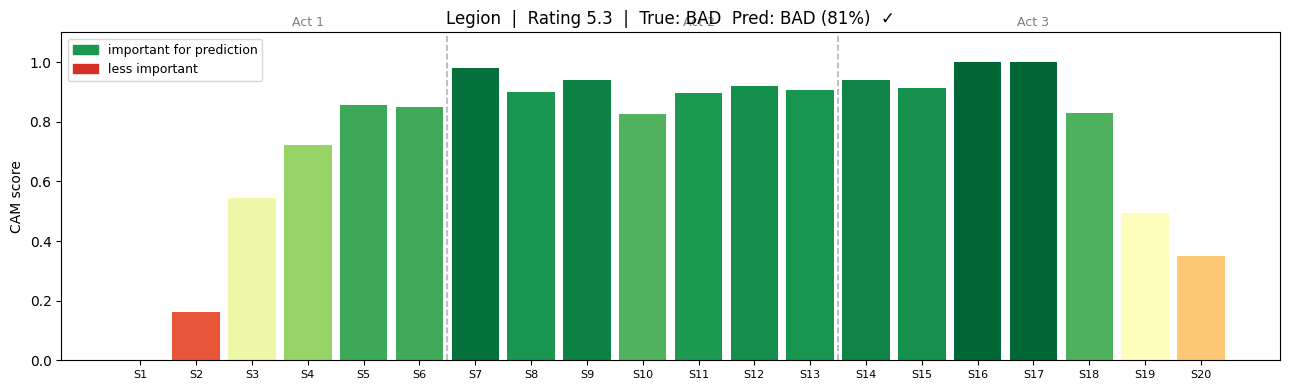


Top 3 important scenes:
  [1] Scene 17 | CAM=1.000
      JEEP                     You were the one who was supposed                     to kill the baby? That was the                     order you didn't obey. Michael nods grimly. Charlie looks urgently at ...
  [2] Scene 16 | CAM=0.999
      And then in moments...      All is QUIET. BEHIND THE COUNTER, Audrey helps Charlie to her feet. She           WINCES. Doubles over, clutching her stomach. CHARLIE                       Oh, no! Michael...
  [3] Scene 7 | CAM=0.979
      He's hurting real bad inside. JEEP                      I couldn't pull the trigger. I                      froze. I saw what I needed to do,                      but I was afraid...                  ...


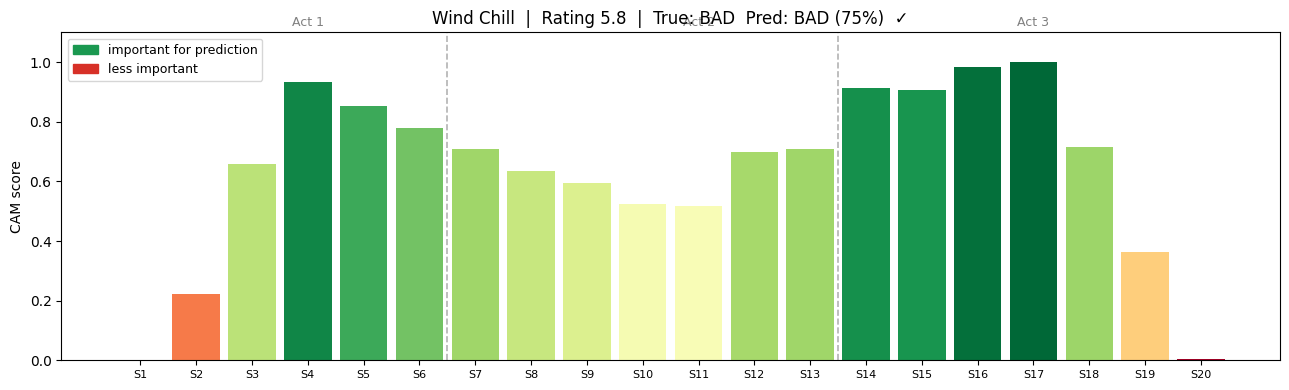


Top 3 important scenes:
  [1] Scene 17 | CAM=1.000
      She uses her sweater cuff to make clean spot on his cheek. Kisses him tenderly. The kiss working it's way to his mouth, lingering a beat. Their lips part. He catches her arm as she reaches for the pow...
  [2] Scene 16 | CAM=0.982
      GUY                Again?! She climbs over into the back seat and crouches down,      urinating as demurely as possible into an empty bottle. GUY (cont'd)                    (teasing)                I...
  [3] Scene 4 | CAM=0.935
      HER POV:       A VENT above the sink, near the ceiling. BACK TO SCENE       She puts a foot up into the sink, testing it to see if it can      take her weight. Then climbs up and straightens on wobbly...


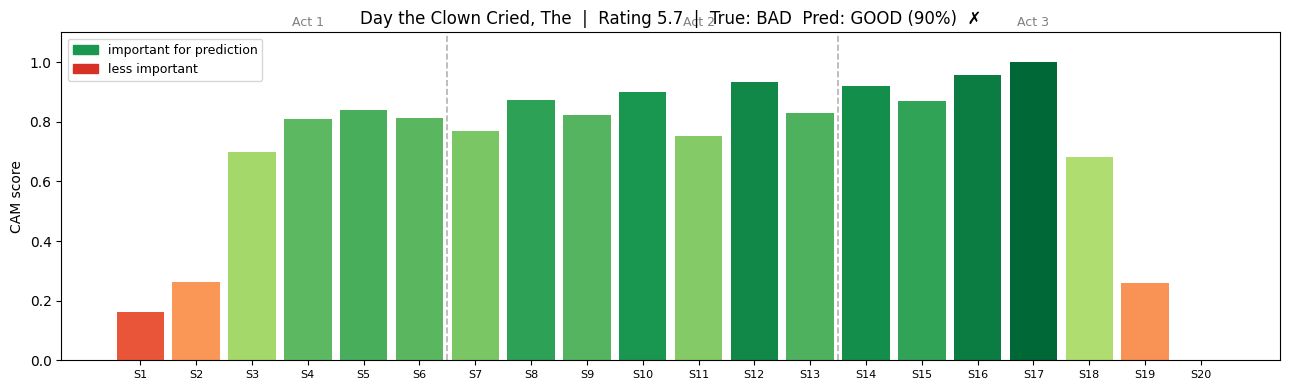


Top 3 important scenes:
  [1] Scene 17 | CAM=1.000
      Sergeant Hoffman is now  	leaning wearily against the boxcar near the door. The CAMERA  	PANS over to the staff car, where Scharff is dozing in the  	back seat. SHOT - SERGEANT HOFFMAN  	From within t...
  [2] Scene 16 | CAM=0.956
      The children watch him big-eyed. A few giggle. HELMUT 		Look, I'm a Jack-in-the-box. He gestures around to indicate that he is, indeed, in a box. HELMUT 		We're all Jacks-in-the-box -- the  		same box...
  [3] Scene 12 | CAM=0.933
      GUARD 		The new Commandant. HELMUT 		Just because I make them laugh a  		little...  				  GUARD 		You know the rule... no mixing with  		Jews. HELMUT 		I wasn't mixing! I was only... The guard stops h...


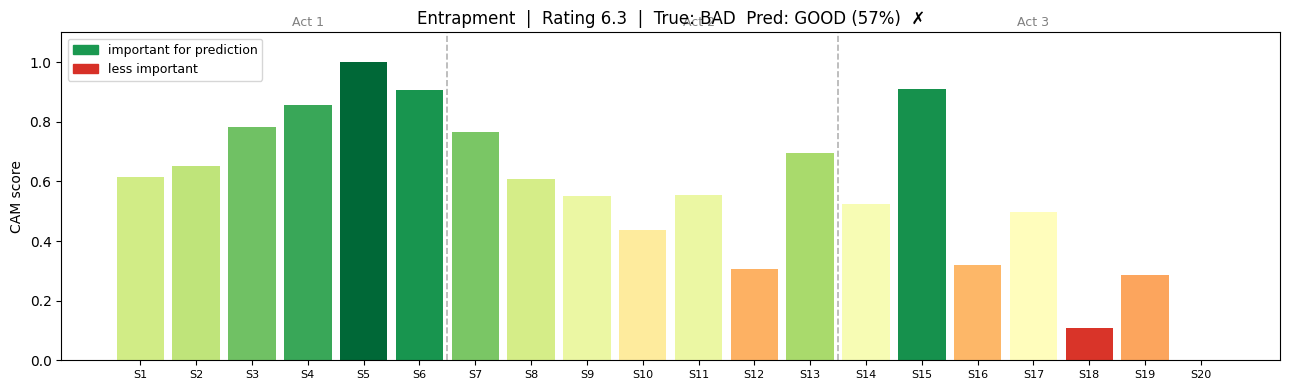


Top 3 important scenes:
  [1] Scene 5 | CAM=1.000
      TAXI DRIVER (O.S., racist accent)                      Still on fo' airport? MAC'S SUITE - LATE NIGHT       A small bottle. An ornate label. Chateau d'Yquem '67. Gin lifts      it from the table, stud...
  [2] Scene 15 | CAM=0.911
      The four guards position themselves around      the triple-paned bulletproof case. It will be a bitch to lift. The official has a key. He inserts this into the lock of the      titanium frame which ho...
  [3] Scene 6 | CAM=0.906
      You will also make 2                      percent of the purchase price. She blinks. MAC                      That's $92,000. And change..                      For two hours work. The look holds. He g...


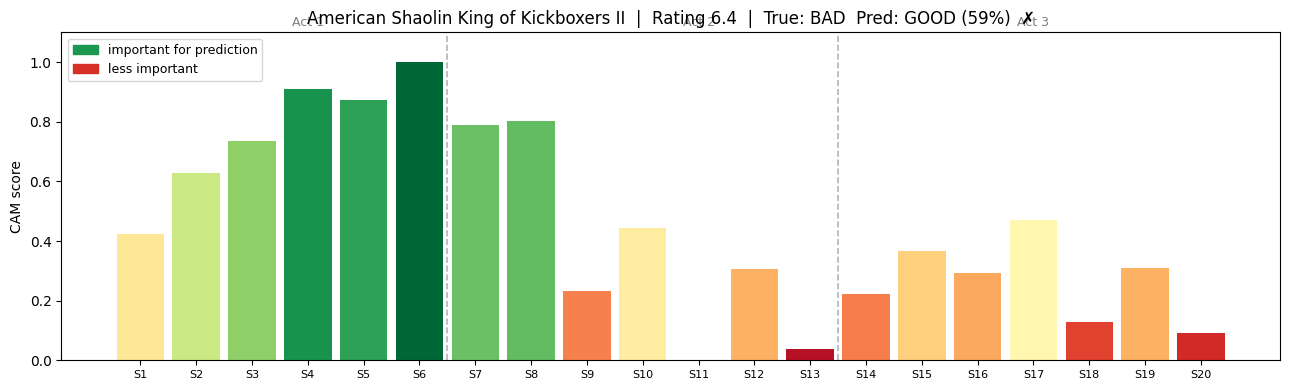


Top 3 important scenes:
  [1] Scene 6 | CAM=1.000
      A crowd has gathered in the courtyard. Ashema and her grandfather are in the crowd, and they work themselves up to where Drew is. Drew turns his head, and a procession of kids about his age (some olde...
  [2] Scene 4 | CAM=0.910
      Neither of them mind ­ in fact, Drew starts looking for more bumps. He pulls around the corner into a wide area lined with drink and food stands. ASHEMA            We are here. DREW STOPS THE BIKE AND...
  [3] Scene 5 | CAM=0.872
      You belong in America. New             York. DREW            I have to do this. I can't go home, not until I'm a monk. I'd be even more of a disgrace... The old man talks to Ashema for the first time....


In [94]:
# Explain first 5 movies
for i in range(min(5, len(val_idx))):
    explain_movie(i, df_clean.iloc[val_idx].reset_index(drop=True),
                  X_val, y_val,
                  scene_proj, arc_conv, classifier_head, N_SCENES)

### Hypotheses

H1 — Climax Hypothesis
Good movies exhibit higher CAM scores in Act 3 compared to bad movies, as they typically contain a well-defined climax and resolution.

H2 — Opening Hook Hypothesis
Good movies exhibit higher CAM scores in Act 1 compared to bad movies, as they establish strong stakes and characters early in the narrative.

H3 — Midpoint Crisis Hypothesis
Good movies exhibit higher CAM scores at the midpoint of Act 2 (scene N/2) compared to bad movies, reflecting a clear midpoint crisis that builds dramatic tension.

H4 — Narrative Arc Hypothesis
Good movies have higher CAM score variance than bad movies, indicating stronger fluctuations across scenes. In contrast, bad movies tend to have flatter CAM distributions, suggesting weaker narrative structure.

H5 — Act 3 Dominance Hypothesis
In good movies, the scene with the highest CAM score is more likely to occur in Act 3 than in Act 1 or Act 2.

In [95]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def collect_cam_by_label(X_scene_tensor, y_tensor,
                          scene_proj, arc_conv, classifier_head, N_SCENES):
    all_cams   = []
    all_labels = []

    scene_proj.eval(); arc_conv.eval(); classifier_head.eval()

    for i in range(len(X_scene_tensor)):
        x = X_scene_tensor[i].unsqueeze(0)
        with torch.no_grad():
            sv  = scene_proj(x)
            af  = arc_conv(sv.transpose(1, 2))
            logits = classifier_head(af.mean(dim=2))
            pred   = logits.argmax(1).item()

        feat = af.squeeze(0).numpy()
        # Use true label, not prediction
        true_label = y_tensor[i].item()
        w   = classifier_head.weight[true_label].detach().numpy()
        cam = (w[:, None] * feat).sum(axis=0)
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        all_cams.append(cam)
        all_labels.append(true_label)

    cams   = np.stack(all_cams)    # (n_movies, N_SCENES)
    labels = np.array(all_labels)  # (n_movies,)

    good_cams = cams[labels == 1]  # (n_good, N_SCENES)
    bad_cams  = cams[labels == 0]  # (n_bad,  N_SCENES)
    return cams, labels, good_cams, bad_cams


def test_all_hypotheses(good_cams, bad_cams, N_SCENES):
    a1_end = N_SCENES // 3
    a2_end = 2 * N_SCENES // 3

    # Per-act mean CAM
    good_act1 = good_cams[:, :a1_end].mean(axis=1)
    good_act2 = good_cams[:, a1_end:a2_end].mean(axis=1)
    good_act3 = good_cams[:, a2_end:].mean(axis=1)
    bad_act1  = bad_cams[:, :a1_end].mean(axis=1)
    bad_act2  = bad_cams[:, a1_end:a2_end].mean(axis=1)
    bad_act3  = bad_cams[:, a2_end:].mean(axis=1)

    print("=" * 60)
    print("HYPOTHESIS TESTING")
    print("=" * 60)

    # H1: Act 3 good > bad
    stat, p = stats.mannwhitneyu(good_act3, bad_act3, alternative="greater")
    print(f"\nH1 — Act 3 good > bad")
    print(f"  Good Act3 mean: {good_act3.mean():.3f}")
    print(f"  Bad  Act3 mean: {bad_act3.mean():.3f}")
    print(f"  Mann-Whitney U={stat:.0f}, p={p:.4f} {'✓ significant' if p < 0.05 else '✗ not significant'}")

    # H2: Act 1 good > bad
    stat, p = stats.mannwhitneyu(good_act1, bad_act1, alternative="greater")
    print(f"\nH2 — Act 1 good > bad")
    print(f"  Good Act1 mean: {good_act1.mean():.3f}")
    print(f"  Bad  Act1 mean: {bad_act1.mean():.3f}")
    print(f"  Mann-Whitney U={stat:.0f}, p={p:.4f} {'✓ significant' if p < 0.05 else '✗ not significant'}")

    # H3: Midpoint crisis (scene between Act 2)
    mid = N_SCENES // 2
    good_mid = good_cams[:, max(0, mid-1):mid+2].mean(axis=1)
    bad_mid  = bad_cams[:, max(0, mid-1):mid+2].mean(axis=1)
    stat, p  = stats.mannwhitneyu(good_mid, bad_mid, alternative="greater")
    print(f"\nH3 — Midpoint good > bad")
    print(f"  Good Mid mean: {good_mid.mean():.3f}")
    print(f"  Bad  Mid mean: {bad_mid.mean():.3f}")
    print(f"  Mann-Whitney U={stat:.0f}, p={p:.4f} {'✓ significant' if p < 0.05 else '✗ not significant'}")

    # H4: CAM variance good > bad (dramatic structure)
    good_var = good_cams.var(axis=1)
    bad_var  = bad_cams.var(axis=1)
    stat, p  = stats.mannwhitneyu(good_var, bad_var, alternative="greater")
    print(f"\nH4 — CAM variance good > bad (dramatic structure)")
    print(f"  Good variance mean: {good_var.mean():.4f}")
    print(f"  Bad  variance mean: {bad_var.mean():.4f}")
    print(f"  Mann-Whitney U={stat:.0f}, p={p:.4f} {'✓ significant' if p < 0.05 else '✗ not significant'}")

    # H5: Peak scene in Act 3 is more with "good" movies
    good_peak_act = (good_cams.argmax(axis=1) >= a2_end).mean()
    bad_peak_act  = (bad_cams.argmax(axis=1)  >= a2_end).mean()
    stat, p = stats.chi2_contingency([
        [(good_cams.argmax(axis=1) >= a2_end).sum(),
         (good_cams.argmax(axis=1) <  a2_end).sum()],
        [(bad_cams.argmax(axis=1)  >= a2_end).sum(),
         (bad_cams.argmax(axis=1)  <  a2_end).sum()]
    ])[:2]
    print(f"\nH5 — Peak scene in Act 3: good={good_peak_act:.1%} vs bad={bad_peak_act:.1%}")
    print(f"  Chi2={stat:.3f}, p={p:.4f} {'✓ significant' if p < 0.05 else '✗ not significant'}")


def plot_hypotheses(good_cams, bad_cams, N_SCENES):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    scenes = range(N_SCENES)
    a1_end = N_SCENES // 3
    a2_end = 2 * N_SCENES // 3

    # Plot 1: Mean CAM per scene
    ax = axes[0]
    ax.plot(scenes, good_cams.mean(axis=0),
            color="#1a9850", linewidth=2, label="Good movies")
    ax.fill_between(scenes,
                    good_cams.mean(axis=0) - good_cams.std(axis=0),
                    good_cams.mean(axis=0) + good_cams.std(axis=0),
                    alpha=0.2, color="#1a9850")
    ax.plot(scenes, bad_cams.mean(axis=0),
            color="#d73027", linewidth=2, label="Bad movies")
    ax.fill_between(scenes,
                    bad_cams.mean(axis=0) - bad_cams.std(axis=0),
                    bad_cams.mean(axis=0) + bad_cams.std(axis=0),
                    alpha=0.2, color="#d73027")
    for b in [a1_end, a2_end]:
        ax.axvline(b - 0.5, color="gray", linestyle="--", alpha=0.5)
    ax.set_title("Mean CAM per scene")
    ax.set_xlabel("Scene")
    ax.set_ylabel("CAM score")
    ax.legend()

    # Plot 2: Per-act boxplot
    ax = axes[1]
    data = [good_cams[:, :a1_end].mean(axis=1),
            bad_cams[:, :a1_end].mean(axis=1),
            good_cams[:, a1_end:a2_end].mean(axis=1),
            bad_cams[:, a1_end:a2_end].mean(axis=1),
            good_cams[:, a2_end:].mean(axis=1),
            bad_cams[:, a2_end:].mean(axis=1)]
    bp = ax.boxplot(data, patch_artist=True,
                    labels=["Act1\nGood","Act1\nBad",
                            "Act2\nGood","Act2\nBad",
                            "Act3\nGood","Act3\nBad"])
    colors = ["#1a9850","#d73027"] * 3
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_title("CAM per act: good vs bad")
    ax.set_ylabel("Mean CAM score")

    # Plot 3: CAM variance distribution
    ax = axes[2]
    ax.hist(good_cams.var(axis=1), bins=15, alpha=0.6,
            color="#1a9850", label="Good", density=True)
    ax.hist(bad_cams.var(axis=1),  bins=15, alpha=0.6,
            color="#d73027", label="Bad",  density=True)
    ax.set_title("CAM variance\n(H4: dramatic structure)")
    ax.set_xlabel("Variance")
    ax.legend()

    plt.tight_layout()
    plt.savefig("hypothesis_test.png", dpi=150, bbox_inches="tight")
    plt.show()

HYPOTHESIS TESTING

H1 — Act 3 good > bad
  Good Act3 mean: 0.371
  Bad  Act3 mean: 0.656
  Mann-Whitney U=349, p=1.0000 ✗ not significant

H2 — Act 1 good > bad
  Good Act1 mean: 0.619
  Bad  Act1 mean: 0.407
  Mann-Whitney U=2108, p=0.0000 ✓ significant

H3 — Midpoint good > bad
  Good Mid mean: 0.584
  Bad  Mid mean: 0.579
  Mann-Whitney U=1417, p=0.4026 ✗ not significant

H4 — CAM variance good > bad (dramatic structure)
  Good variance mean: 0.0860
  Bad  variance mean: 0.0866
  Mann-Whitney U=1298, p=0.6970 ✗ not significant

H5 — Peak scene in Act 3: good=17.3% vs bad=62.3%
  Chi2=20.270, p=0.0000 ✓ significant


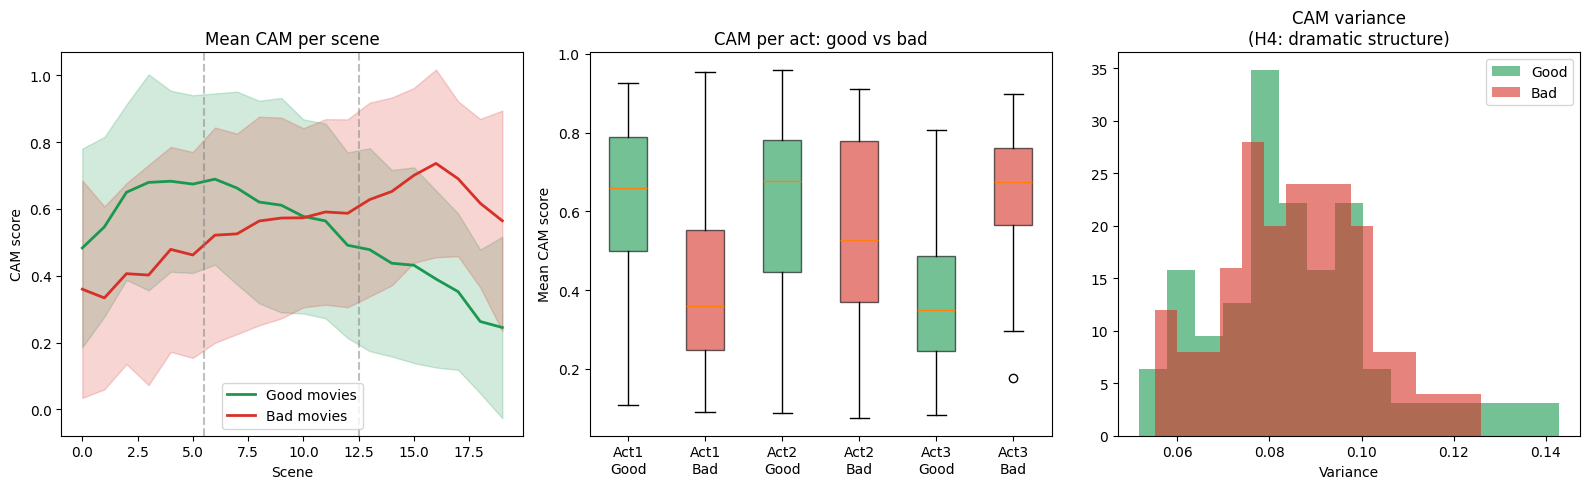

In [96]:
X_test, y_test = prepare_scene_tensors(test_idx, embeddings_list, labels, df_clean, N_SCENES)

cams_test, labels_test, good_cams, bad_cams = collect_cam_by_label(X_test, y_test,scene_proj, arc_conv, classifier_head, N_SCENES)

test_all_hypotheses(good_cams, bad_cams, N_SCENES)
plot_hypotheses(good_cams, bad_cams, N_SCENES)

## Ablation engine

In [97]:
#check
import numpy as np
import torch
import torch.nn.functional as F
from scipy import stats
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

print(f"X_test shape     : {X_test.shape}")        # (n_movies, N_SCENES, feat_dim)
print(f"y_test shape     : {y_test.shape}")         # (n_movies,)
print(f"cams_test shape  : {cams_test.shape}")      # (n_movies, N_SCENES)
print(f"N_SCENES        : {N_SCENES}")
print(f"Good movies     : {(y_test==1).sum().item()}")
print(f"Bad  movies     : {(y_test==0).sum().item()}")
print(f"CAM test range : [{cams_test.min():.3f}, {cams_test.max():.3f}]")

X_test shape     : torch.Size([105, 20, 384])
y_test shape     : torch.Size([105])
cams_test shape  : (105, 20)
N_SCENES        : 20
Good movies     : 52
Bad  movies     : 53
CAM test range : [0.000, 1.000]


In [98]:
def run_ablation(X_tensor, y_tensor,
                 scene_proj, arc_conv, classifier_head,
                 cams, k_list=(1,2,3,5),
                 strategy="top", n_random_seeds=10, mask_value=0.0):
    scene_proj.eval(); arc_conv.eval(); classifier_head.eval()
    N = X_tensor.shape[1]
    results = {}
    for k in k_list:
        accs, drops = [], []
        seeds = range(n_random_seeds) if strategy == "random" else [0]
        for seed in seeds:
            correct, delta = 0, []
            for i in range(len(X_tensor)):
                cam   = cams[i]
                label = y_tensor[i].item()

                if strategy == "top":
                    mask_idx = np.argsort(cam)[::-1][:k]
                elif strategy == "bottom":
                    mask_idx = np.argsort(cam)[:k]
                elif strategy == "middle":
                    mid = N // 2
                    candidates = np.arange(max(0, mid-k), min(N, mid+k))
                    mask_idx = candidates[:k]
                elif strategy == "random":
                    rng = np.random.default_rng(seed * 1000 + i)
                    mask_idx = rng.choice(N, k, replace=False)

                with torch.no_grad():
                    x_orig = X_tensor[i].unsqueeze(0)
                    af_o = arc_conv(scene_proj(x_orig).transpose(1,2))
                    log_o = classifier_head(af_o.mean(dim=2))
                    p_orig = F.softmax(log_o, dim=1)[0][label].item()

                x_m = X_tensor[i].clone()
                x_m[list(mask_idx), :] = mask_value
                with torch.no_grad():
                    af_m = arc_conv(scene_proj(x_m.unsqueeze(0)).transpose(1,2))
                    log_m = classifier_head(af_m.mean(dim=2))
                    pred  = log_m.argmax(1).item()
                    p_mask = F.softmax(log_m, dim=1)[0][label].item()

                correct += (pred == label)
                delta.append(p_orig - p_mask)

            accs.append(correct / len(X_tensor))
            drops.append(np.mean(delta))

        results[k] = {
            "accuracy":  np.mean(accs),  "acc_std":  np.std(accs),
            "conf_drop": np.mean(drops),  "conf_std": np.std(drops),
        }
    return results

In [99]:
def compute_aopc(res_top, res_random):
    ks    = sorted(res_top.keys())
    diffs = [res_top[k]["conf_drop"] - res_random[k]["conf_drop"] for k in ks]
    return np.mean(diffs), diffs, ks

In [100]:
K_LIST = [1, 2, 3, 5]
res = {}
for strat in ["top", "bottom", "middle", "random"]:
    print(f"  → {strat}...", end=" ")
    res[strat] = run_ablation(
        X_test, y_test, scene_proj, arc_conv, classifier_head,
        cams_test, K_LIST, strategy=strat,
        n_random_seeds=(10 if strat=="random" else 1)
    )
    print("done")

aopc, diffs, ks = compute_aopc(res["top"], res["random"])

# result
print("\n" + "="*62)
print(f"{'k':>4} | {'top acc':>8} | {'conf_drop top':>13} | {'conf_drop rnd':>13} | {'ΔAOPC':>7}")
print("-"*62)
for k, d in zip(ks, diffs):
    print(f"{k:>4} | {res['top'][k]['accuracy']:>8.3f} | "
          f"{res['top'][k]['conf_drop']:>13.4f} | "
          f"{res['random'][k]['conf_drop']:>13.4f} | "
          f"{d:>7.4f}")
print("="*62)
print(f"\n>>> AOPC = {aopc:.4f}  ({'GOOD — CAM faithful' if aopc > 0.05 else 'LOW — check model'})")

  → top... done
  → bottom... done
  → middle... done
  → random... done

   k |  top acc | conf_drop top | conf_drop rnd |   ΔAOPC
--------------------------------------------------------------
   1 |    0.676 |        0.0068 |        0.0029 |  0.0039
   2 |    0.667 |        0.0163 |        0.0066 |  0.0096
   3 |    0.638 |        0.0266 |        0.0094 |  0.0172
   5 |    0.619 |        0.0437 |        0.0176 |  0.0261

>>> AOPC = 0.0142  (LOW — check model)


In [101]:
#Normalized AOPC

def run_ablation_relative(X_tensor, y_tensor,
                           scene_proj, arc_conv, classifier_head,
                           cams, k_list=(1,2,3,5), strategy="top"):
    scene_proj.eval(); arc_conv.eval(); classifier_head.eval()
    results = {}
    for k in k_list:
        rel_drops = []
        for i in range(len(X_tensor)):
            cam   = cams[i]
            label = y_tensor[i].item()
            if strategy == "top":
                mask_idx = np.argsort(cam)[::-1][:k]
            elif strategy == "random":
                rng = np.random.default_rng(i)
                mask_idx = rng.choice(X_tensor.shape[1], k, replace=False)

            with torch.no_grad():
                af_o = arc_conv(scene_proj(X_tensor[i].unsqueeze(0)).transpose(1,2))
                p_orig = F.softmax(classifier_head(af_o.mean(dim=2)), dim=1)[0][label].item()

            x_m = X_tensor[i].clone()
            x_m[list(mask_idx), :] = 0.0
            with torch.no_grad():
                af_m = arc_conv(scene_proj(x_m.unsqueeze(0)).transpose(1,2))
                p_mask = F.softmax(classifier_head(af_m.mean(dim=2)), dim=1)[0][label].item()

            rel_drops.append((p_orig - p_mask) / (p_orig + 1e-8))

        results[k] = {"rel_drop": np.mean(rel_drops), "std": np.std(rel_drops)}
    return results

print("Relative AOPC...")
rel_top = run_ablation_relative(X_test, y_test, scene_proj, arc_conv,
                                 classifier_head, cams_test, [1,2,3,5], "top")
rel_rnd = run_ablation_relative(X_test, y_test, scene_proj, arc_conv,
                                 classifier_head, cams_test, [1,2,3,5], "random")

print(f"\n{'k':>4} | {'rel_drop top':>13} | {'rel_drop rnd':>13} | {'ratio':>6}")
print("-"*45)
for k in [1,2,3,5]:
    t = rel_top[k]['rel_drop']; r = rel_rnd[k]['rel_drop']
    print(f"{k:>4} | {t:>13.4f} | {r:>13.4f} | {t/(r+1e-8):>6.2f}×")

aopc_rel = np.mean([rel_top[k]['rel_drop'] - rel_rnd[k]['rel_drop'] for k in [1,2,3,5]])
print(f"\nAOPC (relative) = {aopc_rel:.4f}")

Relative AOPC...

   k |  rel_drop top |  rel_drop rnd |  ratio
---------------------------------------------
   1 |        0.0076 |       -0.0039 |  -1.95×
   2 |        0.0198 |       -0.0057 |  -3.50×
   3 |        0.0325 |       -0.0074 |  -4.39×
   5 |        0.0485 |       -0.0084 |  -5.75×

AOPC (relative) = 0.0335


In [102]:
# Mann-Whitney test: top-k drop vs random drop is significant?
# Use per-movie level, not mean

from scipy import stats as sp_stats

print("Statistical significance test (per-movie level)...\n")
K_TEST = 3

drops_top_per_movie = []
drops_rnd_per_movie = []
rng_b = np.random.default_rng(99)

for i in range(len(X_test)):
    cam   = cams_test[i]
    label = y_test[i].item()
    mask_top = np.argsort(cam)[::-1][:K_TEST]
    mask_rnd = rng_b.choice(N_SCENES, K_TEST, replace=False)

    with torch.no_grad():
        af_o = arc_conv(scene_proj(X_test[i].unsqueeze(0)).transpose(1,2))
        p0 = F.softmax(classifier_head(af_o.mean(dim=2)), dim=1)[0][label].item()

    for mask_idx, store in [(mask_top, drops_top_per_movie),
                             (mask_rnd, drops_rnd_per_movie)]:
        x_m = X_test[i].clone(); x_m[list(mask_idx), :] = 0.0
        with torch.no_grad():
            af_m = arc_conv(scene_proj(x_m.unsqueeze(0)).transpose(1,2))
            pm = F.softmax(classifier_head(af_m.mean(dim=2)), dim=1)[0][label].item()
        store.append(p0 - pm)

stat, p_val = sp_stats.mannwhitneyu(drops_top_per_movie, drops_rnd_per_movie,
                                     alternative="greater")
effect_size = stat / (len(drops_top_per_movie) * len(drops_rnd_per_movie))  # rank-biserial r

print(f"Top-k mean drop  : {np.mean(drops_top_per_movie):.4f} ± {np.std(drops_top_per_movie):.4f}")
print(f"Random mean drop : {np.mean(drops_rnd_per_movie):.4f} ± {np.std(drops_rnd_per_movie):.4f}")
print(f"Mann-Whitney U   : {stat:.0f}")
print(f"p-value          : {p_val:.4f}  {'*** p<0.001' if p_val<0.001 else '** p<0.01' if p_val<0.01 else '* p<0.05' if p_val<0.05 else 'ns'}")
print(f"Effect size (r)  : {effect_size:.3f}  ({'large' if effect_size>0.5 else 'medium' if effect_size>0.3 else 'small'})")

Statistical significance test (per-movie level)...

Top-k mean drop  : 0.0266 ± 0.0265
Random mean drop : 0.0087 ± 0.0287
Mann-Whitney U   : 7522
p-value          : 0.0000  *** p<0.001
Effect size (r)  : 0.682  (large)


## Sufficiency curve

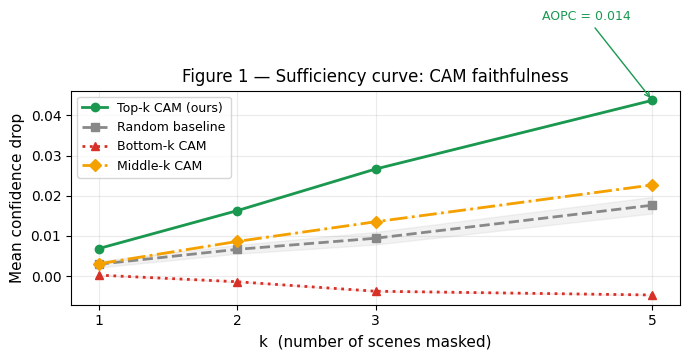

Saved: fig1_sufficiency_curve.pdf


In [103]:
#figure
fig, ax = plt.subplots(figsize=(7, 4))

colors_map = {"top": "#1a9850", "random": "#888888",
              "bottom": "#d73027", "middle": "#f4a100"}
labels_map = {"top": "Top-k CAM (ours)", "random": "Random baseline",
              "bottom": "Bottom-k CAM", "middle": "Middle-k CAM"}
styles_map = {"top": "o-", "random": "s--", "bottom": "^:", "middle": "D-."}

for strat in ["top", "random", "bottom", "middle"]:
    drops = [res[strat][k]["conf_drop"] for k in ks]
    stds  = [res[strat][k]["conf_std"]  for k in ks]
    ax.plot(ks, drops, styles_map[strat],
            color=colors_map[strat], lw=2, label=labels_map[strat])
    ax.fill_between(ks,
                    np.array(drops) - np.array(stds),
                    np.array(drops) + np.array(stds),
                    alpha=0.1, color=colors_map[strat])

# AOPC annotation
ax.annotate(f"AOPC = {aopc:.3f}", xy=(ks[-1], res['top'][ks[-1]]['conf_drop']),
            xytext=(ks[-1]-0.8, res['top'][ks[-1]]['conf_drop']+0.02),
            fontsize=9, color="#1a9850",
            arrowprops=dict(arrowstyle="->", color="#1a9850", lw=1))

ax.set_xlabel("k  (number of scenes masked)", fontsize=11)
ax.set_ylabel("Mean confidence drop", fontsize=11)
ax.set_title("Figure 1 — Sufficiency curve: CAM faithfulness", fontsize=12)
ax.set_xticks(ks)
ax.legend(fontsize=9)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("fig1_sufficiency_curve.pdf", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig1_sufficiency_curve.pdf")

In [104]:
# stratified (good vs bad): if CAM work different between 2 classes

# --- 4a. Stratified ablation ---
print("Stratified ablation (good vs bad)...")
strat_results = {}
for name, mask in [("good", y_test==1), ("bad", y_test==0)]:
    idx = mask.nonzero(as_tuple=True)[0]
    X_s = X_test[idx];  y_s = y_test[idx];  c_s = cams_test[idx.numpy()]
    top_s = run_ablation(X_s, y_s, scene_proj, arc_conv,
                         classifier_head, c_s, K_LIST, "top")
    rnd_s = run_ablation(X_s, y_s, scene_proj, arc_conv,
                         classifier_head, c_s, K_LIST, "random")
    aopc_s, diffs_s, _ = compute_aopc(top_s, rnd_s)
    strat_results[name] = {"top": top_s, "random": rnd_s,
                           "aopc": aopc_s, "diffs": diffs_s}
    print(f"  {name:4s}: AOPC = {aopc_s:.4f}  "
          f"(n={len(idx)}, "
          f"top conf_drop@k=3 = {top_s[3]['conf_drop']:.4f})")

# --- 4b. Per-act sufficiency ---
print("\nPer-act sufficiency (zero-out one act at a time)...")
a1, a2 = N_SCENES//3, 2*N_SCENES//3
act_ranges = {"act1": (0, a1), "act2": (a1, a2), "act3": (a2, N_SCENES)}
act_acc = {}
for act_name, (s, e) in act_ranges.items():
    correct = 0
    for i in range(len(X_test)):
        x = X_test[i].clone();  x[s:e, :] = 0.0
        with torch.no_grad():
            af = arc_conv(scene_proj(x.unsqueeze(0)).transpose(1,2))
            pred = classifier_head(af.mean(dim=2)).argmax(1).item()
        correct += (pred == y_test[i].item())
    act_acc[act_name] = correct / len(X_test)
    print(f"  {act_name} zeroed → acc = {act_acc[act_name]:.3f}")

baseline_acc = res["top"][0]["accuracy"] if 0 in res["top"] else \
               sum(y_test.numpy() == y_test.numpy()) / len(y_test)
# compute baseline (no mask)
correct_base = 0
for i in range(len(X_test)):
    with torch.no_grad():
        af = arc_conv(scene_proj(X_test[i].unsqueeze(0)).transpose(1,2))
        pred = classifier_head(af.mean(dim=2)).argmax(1).item()
    correct_base += (pred == y_test[i].item())
baseline_acc = correct_base / len(X_test)
print(f"\n  Baseline (no mask) → acc = {baseline_acc:.3f}")
print(f"  Drop when remove Act3 : {baseline_acc - act_acc['act3']:.3f}")

Stratified ablation (good vs bad)...
  good: AOPC = 0.0158  (n=52, top conf_drop@k=3 = 0.0239)
  bad : AOPC = 0.0134  (n=53, top conf_drop@k=3 = 0.0293)

Per-act sufficiency (zero-out one act at a time)...
  act1 zeroed → acc = 0.657
  act2 zeroed → acc = 0.648
  act3 zeroed → acc = 0.638

  Baseline (no mask) → acc = 0.676
  Drop when remove Act3 : 0.038


With bad movies: top 3 scene is really important

With bad movies: model does not rely much on top scenes

Act2 > Act3 > Act1

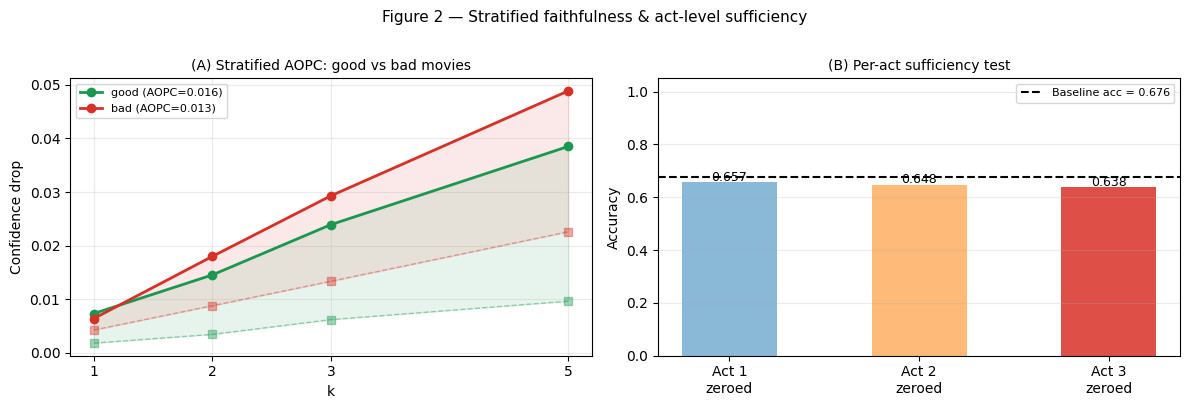

Saved: fig2_stratified_act.pdf


In [105]:

# Figure 2: two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Subplot A: stratified AOPC ---
ax = axes[0]
for name, color in [("good", "#1a9850"), ("bad", "#d73027")]:
    r = strat_results[name]
    drops_t = [r["top"][k]["conf_drop"]    for k in ks]
    drops_r = [r["random"][k]["conf_drop"] for k in ks]
    ax.plot(ks, drops_t, "o-", color=color, lw=2,
            label=f"{name} (AOPC={r['aopc']:.3f})")
    ax.plot(ks, drops_r, "s--", color=color, lw=1, alpha=0.4)
    ax.fill_between(ks, drops_t, drops_r, alpha=0.1, color=color)

ax.set_title("(A) Stratified AOPC: good vs bad movies", fontsize=10)
ax.set_xlabel("k"); ax.set_ylabel("Confidence drop")
ax.set_xticks(ks); ax.legend(fontsize=8); ax.grid(alpha=0.25)

# --- Subplot B: per-act accuracy drop ---
ax = axes[1]
acts_label = ["Act 1\nzeroed", "Act 2\nzeroed", "Act 3\nzeroed"]
acc_tests   = [act_acc[a] for a in ["act1","act2","act3"]]
bar_colors = ["#74add1", "#fdae61", "#d73027"]
bars = ax.bar(acts_label, acc_tests, color=bar_colors, width=0.5, alpha=0.85)
ax.axhline(baseline_acc, color="black", lw=1.5, ls="--",
           label=f"Baseline acc = {baseline_acc:.3f}")
for bar, v in zip(bars, acc_tests):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.005,
            f"{v:.3f}", ha="center", fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Accuracy")
ax.set_title("(B) Per-act sufficiency test", fontsize=10)
ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.25)

plt.suptitle("Figure 2 — Stratified faithfulness & act-level sufficiency",
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig("fig2_stratified_act.pdf", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig2_stratified_act.pdf")

## permutation test (statistical significance)

In [106]:
from tqdm import tqdm

In [107]:
#permutation

N_PERM = 500   
K_TEST = 3

print(f"Permutation test  k={K_TEST}, n_perm={N_PERM}")

# observed
top_k = run_ablation(X_test, y_test, scene_proj, arc_conv,
                     classifier_head, cams_test, [K_TEST], "top")
rnd_k = run_ablation(X_test, y_test, scene_proj, arc_conv,
                     classifier_head, cams_test, [K_TEST], "random",
                     n_random_seeds=10)
aopc_obs = top_k[K_TEST]["conf_drop"] - rnd_k[K_TEST]["conf_drop"]
print(f"Observed AOPC@k={K_TEST} = {aopc_obs:.4f}\n")

# null distribution
rng_perm  = np.random.default_rng(42)
null_tests = []
for perm_i in tqdm(range(N_PERM), desc="Permutations"):
    cams_perm = rng_perm.permuted(cams_test, axis=1)
    t = run_ablation(X_test, y_test, scene_proj, arc_conv,
                     classifier_head, cams_perm, [K_TEST], "top")
    r = run_ablation(X_test, y_test, scene_proj, arc_conv,
                     classifier_head, cams_perm, [K_TEST], "random",
                     n_random_seeds=5)
    null_tests.append(t[K_TEST]["conf_drop"] - r[K_TEST]["conf_drop"])

null_tests = np.array(null_tests)
p_value   = (null_tests >= aopc_obs).mean()
z_score   = (aopc_obs - null_tests.mean()) / (null_tests.std() + 1e-8)

print(f"\n{'='*45}")
print(f"Null mean  : {null_tests.mean():.4f}  ± {null_tests.std():.4f}")
print(f"Observed   : {aopc_obs:.4f}")
print(f"Z-score    : {z_score:.2f}")
print(f"p-value    : {p_value:.4f}  "
      f"{'*** p<0.01' if p_value<0.01 else '** p<0.05' if p_value<0.05 else 'ns'}")
print(f"{'='*45}")

Permutation test  k=3, n_perm=500
Observed AOPC@k=3 = 0.0172



Permutations: 100%|██████████| 500/500 [01:50<00:00,  4.53it/s]


Null mean  : -0.0002  ± 0.0015
Observed   : 0.0172
Z-score    : 12.00
p-value    : 0.0000  *** p<0.01


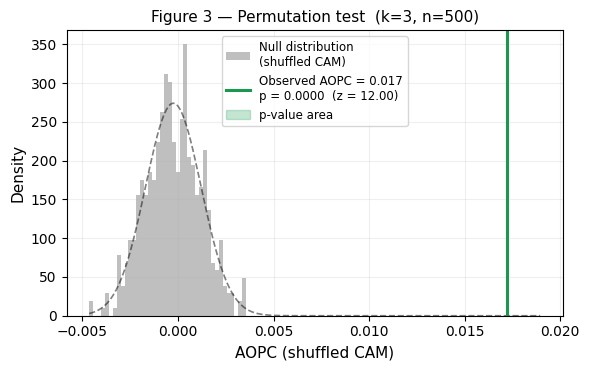

Saved: fig3_permutation_test.pdf


In [108]:

fig, ax = plt.subplots(figsize=(6, 3.8))

ax.hist(null_tests, bins=40, color="#aaaaaa", alpha=0.75,
        density=True, label="Null distribution\n(shuffled CAM)")

from scipy.stats import norm as sp_norm
x_fit = np.linspace(null_tests.min(), max(null_tests.max(), aopc_obs*1.1), 200)
ax.plot(x_fit, sp_norm.pdf(x_fit, null_tests.mean(), null_tests.std()),
        "k--", lw=1.2, alpha=0.5)

# observed line
sig_str = f"p = {p_value:.4f}  (z = {z_score:.2f})"
ax.axvline(aopc_obs, color="#1a9850", lw=2.2,
           label=f"Observed AOPC = {aopc_obs:.3f}\n{sig_str}")

# shade rejection region
x_shade = x_fit[x_fit >= aopc_obs]
ax.fill_between(x_shade,
                sp_norm.pdf(x_shade, null_tests.mean(), null_tests.std()),
                alpha=0.25, color="#1a9850", label=f"p-value area")

ax.set_xlabel("AOPC (shuffled CAM)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title(f"Figure 3 — Permutation test  (k={K_TEST}, n={N_PERM})",
             fontsize=11)
ax.legend(fontsize=8.5)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("fig3_permutation_test.pdf", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig3_permutation_test.pdf")